# Inciso 6.3- 6.6

### Librerías importadas.

In [2]:
pip install xgboost


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 429.7 kB/s eta 0:01:53
    --------------------------------------- 0.8/48.9 MB 588.4 kB/s eta 0:01:22
    --------------------------------------- 1.0/48.9 MB 689.2 kB/s eta 0:01:10
   - -------------------------------------- 1.3/48.9 MB 762.6 k

In [11]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import math
from sklearn.metrics import f1_score, classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit

### Importación de datos.

In [2]:
df = pd.read_csv('datos_predictores_bloques.csv')
df.head(2)

,lago,fecha,bloque_fila,bloque_columna,x,y,b03,b04,b05,b08,ndci,ndvi,ndwi,proporcion_agua,proporcion_tierra,proporcion_otro,chl_a_estimada,pixeles_validos,alta_cianobacteria,id_bloque
0,amatitlan,2025-01-28,1594,754,754500.0,1594500.0,0.132696,0.138698,0.144296,0.184101,0.032449,0.145970,-0.164748,0.009569,0.251196,0.739234,4.664739,418,0,amatitlan_1594_754
1,amatitlan,2025-01-28,1594,755,755500.0,1594500.0,0.088559,0.080894,0.100493,0.206473,0.147543,0.441826,-0.395174,0.003158,0.763158,0.233684,8.154140,950,0,amatitlan_1594_755


### Valores faltantes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7194 entries, 0 to 7193
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lago                7194 non-null   object 
 1   fecha               7194 non-null   object 
 2   bloque_fila         7194 non-null   int64  
 3   bloque_columna      7194 non-null   int64  
 4   x                   7194 non-null   float64
 5   y                   7194 non-null   float64
 6   b03                 7194 non-null   float64
 7   b04                 7194 non-null   float64
 8   b05                 7194 non-null   float64
 9   b08                 7194 non-null   float64
 10  ndci                7194 non-null   float64
 11  ndvi                7194 non-null   float64
 12  ndwi                7194 non-null   float64
 13  proporcion_agua     7194 non-null   float64
 14  proporcion_tierra   7194 non-null   float64
 15  proporcion_otro     7194 non-null   float64
 16  chl_a_

No hay valores faltantes.

### Muestra de datos

In [4]:
proporcion = 0.01
df, _ = train_test_split(df, train_size=proporcion, stratify=df["alta_cianobacteria"], random_state=0)
df = df.reset_index(drop=True)

In [5]:
df.shape

(71, 20)

### Etiquetas y variable objetivo.

In [37]:
columnas_excluir = [
    "lago",
    "fecha",
    "alta_cianobacteria",
    "ndci",
    "chl_a_estimada",
    "b04",
    "b05",
    "id_bloque",
    "celda_fila",
    "celda_columna"
]

X = df.drop(
    columns=columnas_excluir,
    errors="ignore"
)

y = df["alta_cianobacteria"].astype(int)

### Conjunto de entrenamiento y prueba (para la validación aleatoria)

In [38]:
X_train_aleatorio, X_test_aleatorio, y_train_aleatorio, y_test_aleatorio = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

### Conjunto de entrenamiento (para validación espacial)

In [39]:
groups = df["id_bloque"]
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

idx_train_esp, idx_test_esp = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train_esp = X.iloc[idx_train_esp].copy()
X_test_esp = X.iloc[idx_test_esp].copy()

y_train_esp = y.iloc[idx_train_esp].copy()
y_test_esp = y.iloc[idx_test_esp].copy()

groups_train_esp = groups.iloc[idx_train_esp].copy()
groups_test_esp = groups.iloc[idx_test_esp].copy()

In [40]:
#Comprobación de que se ha separado correctamente
assert set(groups_train_esp).isdisjoint(
    set(groups_test_esp)
)

print(
    "Bloques train:",
    groups_train_esp.nunique()
)

print(
    "Bloques test:",
    groups_test_esp.nunique()
)

print(
    "Bloques compartidos:",
    len(
        set(groups_train_esp)
        &
        set(groups_test_esp)
    )
)

Bloques train: 46
Bloques test: 20
Bloques compartidos: 0


## Regresión logística.

### Preprocesamiento a utilizar.

In [41]:
pipeline_rl = Pipeline(steps=[("minmax_scaler", MinMaxScaler()),
                                   ("modelo", LogisticRegression(max_iter=1000, random_state=0))])

### Rejilla de hiperparámetros.

In [42]:
#rejilla_rl = [
#    {
#        "modelo__solver": ["liblinear"],
#        "modelo__penalty": ["l1", "l2"],
#        "modelo__C": [0.01, 0.1, 1, 10]
#    },
#    {
#        "modelo__solver": ["lbfgs"],
#        "modelo__penalty": ["l2"],
#        "modelo__C": [0.01, 0.1, 1, 10]
#    }
#]

rejilla_rl = [{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]

### GridSearch -aleatorio-.

In [43]:
grid_search_rl = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=rejilla_rl,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### GridSearch -espacial-

In [44]:
from sklearn.model_selection import StratifiedGroupKFold

cv_espacial = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
#GRIDSEARCH REGRESIÓN LOGÍSTICA
grid_rl_esp = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=rejilla_rl,
    scoring="f1",
    cv=cv_espacial,
    n_jobs=-1,
    return_train_score=True
)


### Entrenamiento del modelo.

In [45]:
grid_search_rl.fit(X_train_aleatorio, y_train_aleatorio)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"[{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [46]:
grid_rl_esp.fit(X_train_esp,y_train_esp,groups=groups_train_esp) #ESPACIAL

,estimator,Pipeline(step...om_state=0))])
,param_grid,"[{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [47]:
print("Mejores hiperparámetros:", grid_search_rl.best_params_)
print("Mejor accuracy promedio en validación:", grid_search_rl.best_score_)

mejor_lr = grid_search_rl.best_estimator_

Mejores hiperparámetros: {'modelo__C': 10, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
Mejor accuracy promedio en validación: 0.811010101010101


## Random Forest.

### Preprocesamiento a utilizar.

In [48]:
pipeline_rf = Pipeline(steps=[("preprocesamiento", MinMaxScaler(feature_range=(0, 1))),
                              ("modelo", RandomForestClassifier(random_state=42))])

### Rejilla de hiperparámetros.

In [49]:
#rejilla_rf = {
#    "modelo__n_estimators": [50, 100, 200],
#    "modelo__max_depth": [3, 5, 7],
#    "modelo__min_samples_split": [2, 5, 8],
#    "modelo__min_samples_leaf": [1, 2, 4],
#    "modelo__max_features": ["sqrt", "log2"]
#}
rejilla_rf = {
    "modelo__n_estimators": [200],
    "modelo__max_depth": [7],
    "modelo__min_samples_split": [5],
    "modelo__min_samples_leaf": [1],
    "modelo__max_features": ["sqrt"]
}


### GridSearch -Aleatorio-

In [50]:
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rejilla_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### GridSearch -Espacial-

In [51]:
grid_rf_esp = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rejilla_rf,
    scoring="f1",
    cv=cv_espacial,
    n_jobs=-1,
    return_train_score=True
)

### Entrenamiento del modelo.

In [52]:
grid_search_rf.fit(X_train_aleatorio, y_train_aleatorio)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__max_depth': [7], 'modelo__max_features': ['sqrt'], 'modelo__min_samples_leaf': [1], 'modelo__min_samples_split': [5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [53]:
grid_rf_esp.fit(X_train_esp,y_train_esp,groups=groups_train_esp)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__max_depth': [7], 'modelo__max_features': ['sqrt'], 'modelo__min_samples_leaf': [1], 'modelo__min_samples_split': [5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [54]:
print("Mejores hiperparámetros:", grid_search_rf.best_params_)
print("Mejor accuracy en validación:", grid_search_rf.best_score_)
mejor_rf = grid_search_rf.best_estimator_

Mejores hiperparámetros: {'modelo__max_depth': 7, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}
Mejor accuracy en validación: 0.8533333333333333


## XGBoost

### Preprocesamiento a utilizar.

In [55]:
pipeline_xgb = Pipeline(steps=[
    ("preprocesamiento", MinMaxScaler(feature_range=(0, 1))),
    ("modelo", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=0,
        n_jobs=1
    ))
])

### Rejilla de hiperparámetros.

In [56]:
#rejilla_xgb = {
#    "modelo__n_estimators": [100, 200, 300],
#    "modelo__max_depth": [3, 5, 7],
#    "modelo__learning_rate": [0.01, 0.1, 0.2],
#    "modelo__subsample": [0.8, 1.0],
#    "modelo__colsample_bytree": [0.8, 1.0]
#}
rejilla_xgb = {
    "modelo__n_estimators": [300],
    "modelo__max_depth": [5],
    "modelo__learning_rate": [0.1],
    "modelo__subsample": [1.0],
    "modelo__colsample_bytree": [1.0]
}

### GridSearch -aleatorio-

In [58]:
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=rejilla_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### GridSearch -espacial-

In [59]:
grid_xgb_esp = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=rejilla_xgb,
    scoring="f1",
    cv=cv_espacial,
    n_jobs=-1,
    return_train_score=True
)

### Entrenamiento del modelo.

In [60]:
grid_search_xgb.fit(X_train_aleatorio, y_train_aleatorio)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'modelo__colsample_bytree': [1.0], 'modelo__learning_rate': [0.1], 'modelo__max_depth': [5], 'modelo__n_estimators': [300], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [61]:
grid_xgb_esp.fit(X_train_esp,y_train_esp,groups=groups_train_esp) #espacial

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'modelo__colsample_bytree': [1.0], 'modelo__learning_rate': [0.1], 'modelo__max_depth': [5], 'modelo__n_estimators': [300], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [23]:
mejor_xgb = grid_search_xgb.best_estimator_
print("Mejor accuracy en validación:", grid_search_xgb.best_score_)
print("Mejores hiperparámetros:", grid_search_xgb.best_params_)

Mejor accuracy en validación: 0.9006115695061
Mejores hiperparámetros: {'modelo__colsample_bytree': 1.0, 'modelo__learning_rate': 0.1, 'modelo__max_depth': 5, 'modelo__n_estimators': 300, 'modelo__subsample': 1.0}


## Elección de hiperparámetros.

$\textbf{Regresión logística}$  
C: Se usa para evitar el sobreajuste. [0.01, 0.1, 1, 10].  
penalty: Técnica usada para evitar el sobreajuste. [l1, l2].  
solver: Algoritmo optimizador. [liblinear, lbfgs].  


$\textbf{Random Forest}$  
n_estimators: Cantidad de árboles. [50, 100, 200].  
max_depth": Profundida máxima de árboles. [3, 5, 7].  
min_samples_split: Número de muestras mínimo para ser dividido. [2, 5, 8].  
min_samples_leaf: Mínimo de muestras que debe tener una hoja [1, 2, 4].  
max_features: Cantidad máxima de características [sqrt, log2].  


$\textbf{XGBoost}$
n_estimators: Cantidad de árboles construidos secuencialmente. [100, 200, 300].
max_depth: Máxima profundidad de cada árbol [3, 5, 7].
learning_rate: Determina cuánto contribuye cada nuevo árbol al modelo. [0.01, 0.1, 0.2].
subsample: Proporción de filas utilizadas para entrenar cada árbol. [0.8, 1.0].
colsample_bytree: Proporción de variables utilizadas para construir cada árbol. [0.8, 1.0].


Se usará el F1 score como la métrica con la que se elige el mejor modelo, esto debido a que le dará la misma importancia a falsos positivos como falsos negativos, sin importar el desbalance.

## Evaluación en el conjunto de prueba.

In [24]:
y_pred_rl = mejor_lr.predict(X_test_aleatorio)
y_pred_rf = mejor_rf.predict(X_test_aleatorio)
y_pred_xgb = mejor_xgb.predict(X_test_aleatorio)

# Cálculo del F1 score
f1_rl = f1_score(y_test_aleatorio, y_pred_rl, zero_division=0)
f1_rf = f1_score(y_test_aleatorio, y_pred_rf, zero_division=0)
f1_xgb = f1_score(y_test_aleatorio, y_pred_xgb, zero_division=0)

# Tabla comparativa
resultados_f1 = pd.DataFrame({
    "Modelo": ["Regresión logística", "Random Forest", "XGBoost"],
    "F1 score": [f1_rl, f1_rf, f1_xgb]
}).sort_values("F1 score", ascending=False).reset_index(drop=True)

display(resultados_f1)

,Modelo,F1 score
0,XGBoost,0.900120
1,Random Forest,0.881598
2,Regresión logística,0.877329


Con el criterio de F1 score, se toma como el mejor modelo el XGBoost.

### Reporte de clasificación.

In [36]:
print('           Reporte de Regresión Logística               ')
print('--------------------------------------------------------')
print(classification_report(y_test, y_pred_rl, target_names=["Baja presencia", "Alta presencia"], digits=4, zero_division=0))

           Reporte de Regresión Logística               
--------------------------------------------------------
                precision    recall  f1-score   support

Baja presencia     0.9397    0.9047    0.9218     31250
Alta presencia     0.8520    0.9043    0.8773     18958

      accuracy                         0.9045     50208
     macro avg     0.8958    0.9045    0.8996     50208
  weighted avg     0.9066    0.9045    0.9050     50208



In [37]:
print('               Reporte de Random Forest                 ')
print('--------------------------------------------------------')
print(classification_report(y_test, y_pred_rf, target_names=["Baja presencia", "Alta presencia"], digits=4, zero_division=0))

               Reporte de Random Forest                 
--------------------------------------------------------
                precision    recall  f1-score   support

Baja presencia     0.9401    0.9107    0.9251     31250
Alta presencia     0.8600    0.9043    0.8816     18958

      accuracy                         0.9083     50208
     macro avg     0.9000    0.9075    0.9034     50208
  weighted avg     0.9098    0.9083    0.9087     50208



In [38]:
print('                  Reporte de XGBoost                    ')
print('--------------------------------------------------------')
print(classification_report(y_test, y_pred_xgb, target_names=["Baja presencia", "Alta presencia"], digits=4, zero_division=0))

                  Reporte de XGBoost                    
--------------------------------------------------------
                precision    recall  f1-score   support

Baja presencia     0.9451    0.9315    0.9382     31250
Alta presencia     0.8897    0.9108    0.9001     18958

      accuracy                         0.9237     50208
     macro avg     0.9174    0.9211    0.9192     50208
  weighted avg     0.9242    0.9237    0.9238     50208



El XGBoost fue superior en precision, recall y en f1-score para cada una de las clases.

### ROC-AUC.

In [39]:
y_proba_lr = mejor_lr.predict_proba(X_test_aleatorio)[:, 1]

print("Regresion logística")
print(f"ROC-AUC: {roc_auc_score(y_test_aleatorio, y_proba_lr):.4f}")

Regresion logística
ROC-AUC: 0.9692


In [40]:
y_proba_rf = mejor_rf.predict_proba(X_test_aleatorio)[:, 1]

print("Random Forest")
print(f"ROC-AUC: {roc_auc_score(y_test_aleatorio, y_proba_rf):.4f}")

Random Forest
ROC-AUC: 0.9717


In [41]:
y_proba_xgb = mejor_xgb.predict_proba(X_test_aleatorio)[:, 1]

print("XGBoost")
print(f"ROC-AUC: {roc_auc_score(y_test_aleatorio, y_proba_xgb):.4f}")

XGBoost
ROC-AUC: 0.9801


XGBoost también presentó un mayor ROC-AUC que los otros modelos, por lo que comete menos errores que los otros.

### Matrices de confusión.

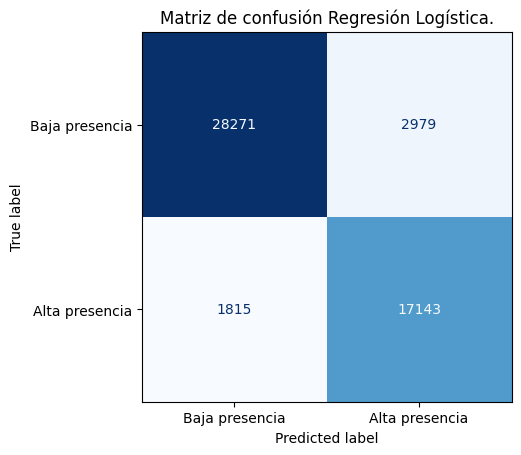

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rl, display_labels=["Baja presencia", "Alta presencia"],
                                        cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión Regresión Logística.")
plt.show()

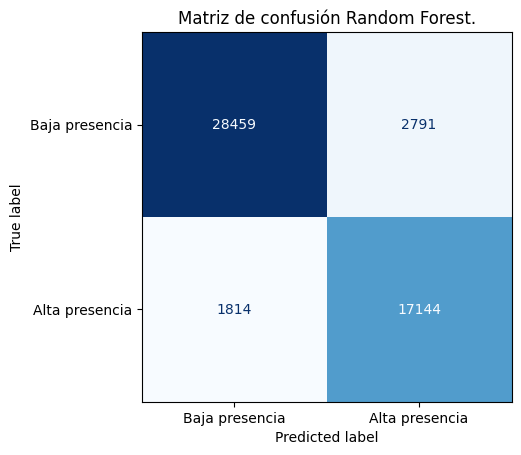

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=["Baja presencia", "Alta presencia"],
                                        cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión Random Forest.")
plt.show()

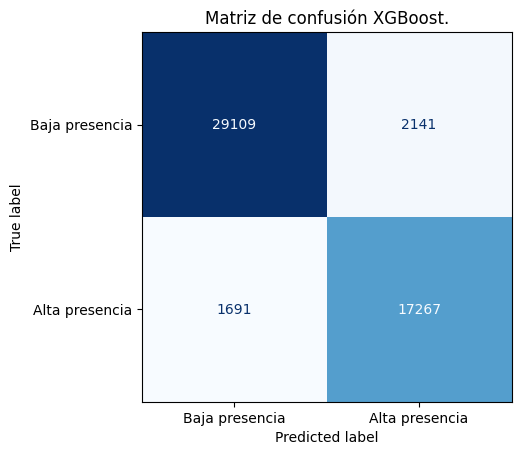

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=["Baja presencia", "Alta presencia"],
                                        cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión XGBoost.")
plt.show()